# Quantum-Secure 6G STINs: Pioneering Architecture-Centric Security Framework

## Project idea
This notebook implements a **Q1-oriented, pioneering prototype** for quantum-secure **6G Satellite–Terrestrial Integrated Networks (STINs)**. Rather than treating security as a local property of isolated links, the notebook models security as a **network-wide architectural phenomenon** emerging from the interaction of space, air, and ground layers; hybrid **QKD + PQC** resources; trust exposure; and dynamic channel conditions.

## Projected objectives
1. Build a multi-layer STIN demonstrator with dynamic quantum and classical security resources.
2. Compute a **Quantum Security Functional** that jointly captures security benefit, latency cost, and structural risk.
3. Define and evaluate a **Security Criticality Index (SCI)** to characterize sparse, transition, and saturation regimes of quantum-secure operation.
4. Implement a **decision-centric hybrid allocation algorithm** that selects routes and allocates resources under time-varying conditions.
5. Generate reproducible figures, tables, and an `outputs_summary.txt` file to support the development of a stronger journal manuscript.

## Deliverable
The deliverable is a **research-grade demonstrator notebook** that links theory, mathematics, and algorithmic decision-making in a single pipeline. It is designed as the starting prototype for a pioneering article and can later be extended toward learning-based adaptive control, larger STIN scenarios, and more realistic satellite quantum channel models.


## Environment setup

This cell imports the required libraries, mounts Google Drive when executed in Colab, and prepares the output directory structure. The updated notebook stores figures, tables, and a consolidated text summary for the **pioneering architecture-centric prototype**.


In [11]:
import os
import math
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

try:
    from google.colab import drive  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

PROJECT_NAME = "quantum_secure_comm"

if IN_COLAB:
    drive.mount('/content/drive', force_remount=True)
    ROOT_DIR = Path(f'/content/drive/MyDrive/Outputs/{PROJECT_NAME}')
else:
    ROOT_DIR = Path(f'./Outputs/{PROJECT_NAME}')

FIG_DIR = ROOT_DIR / 'figures'
TAB_DIR = ROOT_DIR / 'tables'
OTH_DIR = ROOT_DIR / 'others'
for d in [ROOT_DIR, FIG_DIR, TAB_DIR, OTH_DIR]:
    d.mkdir(parents=True, exist_ok=True)

OUTPUTS_SUMMARY_PATH = ROOT_DIR / 'outputs_summary.txt'
print(f"[INFO] Root output directory: {ROOT_DIR.resolve()}")


[INFO] Root output directory: F:\MBZUAI UAE\13-Quantum-Secure-Comm\GitHub\Quantum-Secure-Communication-Architectures\Outputs\quantum_secure_comm


## Unified theoretical quantities and utility functions

This cell defines the mathematical ingredients of the upgraded framework: a surrogate quantum key-rate model, a trust-aware hybrid security formulation, the **Quantum Security Functional**, the **Security Criticality Index (SCI)**, and helper functions for path-level evaluation.


In [2]:
def qkd_rate(transmissivity: float, excess_noise: float, qber: float) -> float:
    """Simplified surrogate QKD rate based on transmissivity, noise, and QBER."""
    transmissivity = float(np.clip(transmissivity, 1e-6, 0.999999))
    excess_noise = max(0.0, float(excess_noise))
    qber = float(np.clip(qber, 0.0, 0.499))
    plob_bound = -np.log2(1.0 - transmissivity)
    penalty = np.exp(-2.0 * excess_noise) * max(0.0, 1.0 - 2.0 * qber)
    return max(0.0, plob_bound * penalty)

def pqc_rate(link_capacity: float, security_margin: float) -> float:
    """Simplified post-quantum secure rate proxy."""
    return max(0.0, float(link_capacity) * float(security_margin))

def node_type(name: str) -> str:
    if name.startswith("SAT"):
        return "satellite"
    if name.startswith("UAV"):
        return "aerial"
    return "terrestrial"

def trust_penalty(trust_path: float, beta: float = 0.18) -> float:
    """Penalty increases when the average path trust decreases."""
    trust_path = float(np.clip(trust_path, 1e-6, 1.0))
    return beta * (1.0 - trust_path)

def hybrid_security_level(q_path: float, p_path: float, trust_path: float, alpha: float = 0.70, beta: float = 0.18) -> float:
    """Hybrid quantum-classical security level with trust-aware penalty."""
    base = alpha * q_path + (1.0 - alpha) * p_path
    penalty = trust_penalty(trust_path, beta=beta)
    return max(0.0, base - penalty)

def path_degradation_operator(path_edges_metrics: list[dict]) -> float:
    """Cumulative quantum degradation across the path."""
    val = 1.0
    for m in path_edges_metrics:
        val *= (1.0 - float(np.clip(m["transmissivity"], 0.0, 0.999999)))
    return float(val)

def path_risk(path_edges_metrics: list[dict]) -> float:
    """Structural risk from low trust and noisy / high-QBER links."""
    risk_terms = []
    for m in path_edges_metrics:
        risk_terms.append(
            0.45 * (1.0 - m["trust_score"]) +
            0.30 * m["excess_noise"] +
            0.25 * m["qber"]
        )
    return float(np.mean(risk_terms)) if risk_terms else 0.0

def path_latency(path_edges_metrics: list[dict]) -> float:
    return float(np.sum([m["latency_ms"] for m in path_edges_metrics])) if path_edges_metrics else 0.0

def communication_cost(latency_ms: float, hop_count: int, norm_latency: float = 120.0) -> float:
    latency_term = latency_ms / norm_latency
    hop_term = hop_count / 8.0
    return float(0.75 * latency_term + 0.25 * hop_term)

def nonlinear_security_value(security_level: float, q_path: float, trust_path: float) -> float:
    """Nonlinear coupling inspired by the theoretical security functional."""
    return float(np.log1p(max(security_level, 0.0)) * (1.0 + np.sqrt(max(q_path, 0.0))) * np.clip(trust_path, 0.0, 1.0))

def quantum_security_functional(security_level: float, q_path: float, trust_path: float, latency_ms: float, risk_val: float, weight: float, lam: float = 0.28, gamma: float = 0.42) -> float:
    benefit = nonlinear_security_value(security_level, q_path, trust_path)
    cost = communication_cost(latency_ms, hop_count=1 + int(latency_ms // 20))
    return float(weight * benefit - lam * cost - gamma * risk_val)

def security_feasible(security_level: float, security_req: float) -> bool:
    return bool(security_level >= security_req)

def security_criticality_index(feasible_ratio: float, mean_q_path: float, mean_p_path: float, eps: float = 1e-6) -> float:
    return float(feasible_ratio * (mean_q_path / (mean_p_path + eps)))

def classify_security_regime(sci: float) -> str:
    if sci < 0.020:
        return "sparse"
    if sci < 0.080:
        return "transition"
    return "saturation"

print("[INFO] Unified utility functions are ready.")


[INFO] Unified utility functions are ready.


## Multi-layer STIN topology construction

This cell creates a synthetic but more expressive STIN demonstrator that distinguishes **space, air, gateway, base-station, and data-center roles**. Each link receives baseline physical, trust, and capacity properties that evolve over time.


In [4]:
G = nx.Graph()

nodes = [
    "SAT_1", "SAT_2",
    "UAV_1", "UAV_2",
    "GW_1", "GW_2",
    "BS_1", "BS_2", "BS_3", "DC_1"
]
G.add_nodes_from(nodes)

for n in G.nodes():
    G.nodes[n]["layer"] = node_type(n)

edges = [
    ("SAT_1", "SAT_2"),
    ("SAT_1", "UAV_1"),
    ("SAT_2", "UAV_2"),
    ("SAT_1", "GW_1"),
    ("SAT_2", "GW_2"),
    ("UAV_1", "GW_1"),
    ("UAV_2", "GW_2"),
    ("UAV_1", "BS_2"),
    ("UAV_2", "BS_2"),
    ("GW_1", "BS_1"),
    ("GW_1", "BS_2"),
    ("GW_2", "BS_2"),
    ("GW_2", "BS_3"),
    ("BS_1", "DC_1"),
    ("BS_2", "DC_1"),
    ("BS_3", "DC_1"),
    ("BS_1", "BS_2"),
    ("BS_2", "BS_3"),
]

G.add_edges_from(edges)

for u, v in G.edges():
    pair_type = {node_type(u), node_type(v)}

    if "satellite" in pair_type:
        base_trans = np.random.uniform(0.18, 0.52)
        base_noise = np.random.uniform(0.010, 0.055)
        latency = np.random.uniform(18, 42)
        trust = np.random.uniform(0.66, 0.90)
        capacity = np.random.uniform(6, 16)
    elif "aerial" in pair_type:
        base_trans = np.random.uniform(0.28, 0.66)
        base_noise = np.random.uniform(0.010, 0.070)
        latency = np.random.uniform(7, 18)
        trust = np.random.uniform(0.72, 0.93)
        capacity = np.random.uniform(8, 20)
    else:
        base_trans = np.random.uniform(0.58, 0.92)
        base_noise = np.random.uniform(0.004, 0.035)
        latency = np.random.uniform(1, 9)
        trust = np.random.uniform(0.82, 0.98)
        capacity = np.random.uniform(10, 28)

    G[u][v]["base_transmissivity"] = base_trans
    G[u][v]["base_noise"] = base_noise
    G[u][v]["base_qber"] = np.random.uniform(0.008, 0.070)
    G[u][v]["link_capacity"] = capacity
    G[u][v]["security_margin"] = np.random.uniform(0.76, 0.97)
    G[u][v]["trust_score"] = trust
    G[u][v]["latency_ms"] = latency

print(f"[INFO] Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")
edge_preview = pd.DataFrame([
    {
        "u": u,
        "v": v,
        "layer_u": G.nodes[u]["layer"],
        "layer_v": G.nodes[v]["layer"],
        "base_transmissivity": G[u][v]["base_transmissivity"],
        "base_noise": G[u][v]["base_noise"],
        "trust_score": G[u][v]["trust_score"],
        "latency_ms": G[u][v]["latency_ms"],
    }
    for u, v in G.edges()
])
display(edge_preview.head())


[INFO] Nodes: 10, Edges: 18


,u,v,layer_u,layer_v,base_transmissivity,base_noise,trust_score,latency_ms
0,SAT_1,SAT_2,satellite,satellite,0.458125,0.048733,0.782579,18.166851
1,SAT_1,UAV_1,satellite,aerial,0.294789,0.052431,0.784510,25.756870
2,SAT_1,GW_1,satellite,terrestrial,0.507232,0.021330,0.732211,29.933964
3,SAT_2,UAV_2,satellite,aerial,0.350911,0.012317,0.877984,24.687515
4,SAT_2,GW_2,satellite,terrestrial,0.515121,0.020892,0.842789,34.131253


## Dynamic link-state simulation with time-varying channels

This cell simulates stochastic evolution of transmissivity, noise, QBER, QKD rate, and PQC rate over time. These link states provide the dynamic environment in which the decision-centric security algorithm operates.


In [5]:
T = 16
records = []

for t in range(T):
    seasonal_term = 0.03 * np.sin(2 * np.pi * t / T)
    for u, v, data in G.edges(data=True):
        trans = np.clip(
            data["base_transmissivity"] + seasonal_term + np.random.normal(0, 0.04),
            0.02, 0.98
        )
        noise = np.clip(
            data["base_noise"] + np.random.normal(0, 0.009),
            0.001, 0.20
        )
        qber = np.clip(
            data["base_qber"] + np.random.normal(0, 0.010),
            0.001, 0.25
        )

        q_rate = qkd_rate(trans, noise, qber)
        p_rate = pqc_rate(data["link_capacity"], data["security_margin"])

        records.append({
            "time": t,
            "u": u,
            "v": v,
            "transmissivity": trans,
            "excess_noise": noise,
            "qber": qber,
            "q_rate": q_rate,
            "p_rate": p_rate,
            "trust_score": data["trust_score"],
            "latency_ms": data["latency_ms"]
        })

link_df = pd.DataFrame(records)
link_df.to_csv(TAB_DIR / "simulated_link_states.csv", index=False)
display(link_df.head())
print(f"[SAVED] {TAB_DIR / 'simulated_link_states.csv'}")


,time,u,v,transmissivity,excess_noise,qber,q_rate,p_rate,trust_score,latency_ms
0,0,SAT_1,SAT_2,0.440264,0.056440,0.023912,0.712056,7.988424,0.782579,18.166851
1,0,SAT_1,UAV_1,0.244960,0.053990,0.034398,0.338849,12.562070,0.784510,25.756870
2,0,SAT_1,GW_1,0.471878,0.022714,0.010869,0.861018,7.857459,0.732211,29.933964
3,0,SAT_2,UAV_2,0.305192,0.015537,0.022591,0.486233,7.243615,0.877984,24.687515
4,0,SAT_2,GW_2,0.558443,0.030377,0.039373,1.022421,7.012990,0.842789,34.131253


[SAVED] Outputs\quantum_secure_comm\tables\simulated_link_states.csv


## Flow definitions and candidate security paths

This cell defines communication demands with security requirements and priorities. Candidate simple paths are then enumerated so the notebook can compare feasible and infeasible security-routing choices at each time step.


In [6]:
flows = [
    {"flow_id": "F1", "src": "SAT_1", "dst": "DC_1", "security_req": 1.25, "priority": 1.00},
    {"flow_id": "F2", "src": "SAT_2", "dst": "BS_1", "security_req": 1.05, "priority": 0.92},
    {"flow_id": "F3", "src": "UAV_1", "dst": "DC_1", "security_req": 0.95, "priority": 0.85},
    {"flow_id": "F4", "src": "GW_2", "dst": "BS_1", "security_req": 0.82, "priority": 0.78},
]

candidate_paths = {}
for flow in flows:
    all_paths = list(nx.all_simple_paths(G, flow["src"], flow["dst"], cutoff=5))
    candidate_paths[flow["flow_id"]] = all_paths[:6]

for fid, paths in candidate_paths.items():
    print(fid, "->", len(paths), "candidate paths")
    for p in paths[:3]:
        print("   ", p)


F1 -> 6 candidate paths
    ['SAT_1', 'SAT_2', 'UAV_2', 'GW_2', 'BS_2', 'DC_1']
    ['SAT_1', 'SAT_2', 'UAV_2', 'GW_2', 'BS_3', 'DC_1']
    ['SAT_1', 'SAT_2', 'UAV_2', 'BS_2', 'DC_1']
F2 -> 6 candidate paths
    ['SAT_2', 'SAT_1', 'UAV_1', 'GW_1', 'BS_1']
    ['SAT_2', 'SAT_1', 'UAV_1', 'GW_1', 'BS_2', 'BS_1']
    ['SAT_2', 'SAT_1', 'UAV_1', 'BS_2', 'GW_1', 'BS_1']
F3 -> 6 candidate paths
    ['UAV_1', 'SAT_1', 'SAT_2', 'UAV_2', 'BS_2', 'DC_1']
    ['UAV_1', 'SAT_1', 'SAT_2', 'GW_2', 'BS_2', 'DC_1']
    ['UAV_1', 'SAT_1', 'SAT_2', 'GW_2', 'BS_3', 'DC_1']
F4 -> 6 candidate paths
    ['GW_2', 'SAT_2', 'SAT_1', 'UAV_1', 'GW_1', 'BS_1']
    ['GW_2', 'SAT_2', 'SAT_1', 'UAV_1', 'BS_2', 'BS_1']
    ['GW_2', 'SAT_2', 'SAT_1', 'GW_1', 'BS_1']


## Decision-centric hybrid security allocation algorithm

This cell implements the upgraded algorithm. For every flow and time step, it evaluates candidate paths using the hybrid security level, structural risk, path degradation, and the global **Quantum Security Functional**. The cell also computes the **Security Criticality Index (SCI)** and identifies the operating regime of the network.


In [7]:
def get_edge_row(link_states: pd.DataFrame, time_t: int, a: str, b: str) -> pd.Series:
    mask = (
        (link_states["time"] == time_t) &
        (
            ((link_states["u"] == a) & (link_states["v"] == b)) |
            ((link_states["u"] == b) & (link_states["v"] == a))
        )
    )
    return link_states.loc[mask].iloc[0]

def evaluate_path_at_time(path, time_t, link_states):
    edge_metrics = []
    for a, b in zip(path[:-1], path[1:]):
        row = get_edge_row(link_states, time_t, a, b)
        edge_metrics.append({
            "transmissivity": float(row["transmissivity"]),
            "excess_noise": float(row["excess_noise"]),
            "qber": float(row["qber"]),
            "q_rate": float(row["q_rate"]),
            "p_rate": float(row["p_rate"]),
            "trust_score": float(row["trust_score"]),
            "latency_ms": float(row["latency_ms"]),
        })

    q_path = min(m["q_rate"] for m in edge_metrics)
    p_path = min(m["p_rate"] for m in edge_metrics)
    trust_path = float(np.mean([m["trust_score"] for m in edge_metrics]))
    latency_ms = path_latency(edge_metrics)
    risk_val = path_risk(edge_metrics)
    degradation = path_degradation_operator(edge_metrics)
    sec_level = hybrid_security_level(q_path, p_path, trust_path)
    return {
        "q_path": q_path,
        "p_path": p_path,
        "trust_path": trust_path,
        "latency_path": latency_ms,
        "risk_path": risk_val,
        "degradation_path": degradation,
        "security_level": sec_level,
        "hop_count": len(path) - 1,
    }

allocation_results = []

for t in range(T):
    time_candidates = []
    for flow in flows:
        best = None
        for path in candidate_paths[flow["flow_id"]]:
            metrics = evaluate_path_at_time(path, t, link_df)
            feasible = security_feasible(metrics["security_level"], flow["security_req"])
            f_sec = quantum_security_functional(
                security_level=metrics["security_level"],
                q_path=metrics["q_path"],
                trust_path=metrics["trust_path"],
                latency_ms=metrics["latency_path"],
                risk_val=metrics["risk_path"],
                weight=flow["priority"],
            )
            candidate = {
                "time": t,
                "flow_id": flow["flow_id"],
                "src": flow["src"],
                "dst": flow["dst"],
                "path": " -> ".join(path),
                "security_req": flow["security_req"],
                "priority": flow["priority"],
                "feasible": feasible,
                "functional_score": f_sec,
                **metrics,
            }
            if (best is None) or (candidate["functional_score"] > best["functional_score"]):
                best = candidate
        allocation_results.append(best)
        time_candidates.append(best)

alloc_df = pd.DataFrame(allocation_results)

summary_time_pre = alloc_df.groupby("time").agg(
    feasible_ratio=("feasible", "mean"),
    mean_q_path=("q_path", "mean"),
    mean_p_path=("p_path", "mean"),
).reset_index()
summary_time_pre["SCI"] = summary_time_pre.apply(
    lambda r: security_criticality_index(r["feasible_ratio"], r["mean_q_path"], r["mean_p_path"]),
    axis=1
)
summary_time_pre["regime"] = summary_time_pre["SCI"].apply(classify_security_regime)

alloc_df = alloc_df.merge(summary_time_pre[["time", "SCI", "regime"]], on="time", how="left")
display(alloc_df.head())


,time,flow_id,src,dst,path,security_req,priority,feasible,functional_score,q_path,p_path,trust_path,latency_path,risk_path,degradation_path,security_level,hop_count,SCI,regime
0,0,F1,SAT_1,DC_1,SAT_1 -> SAT_2 -> UAV_2 -> BS_2 -> BS_3 -> DC_1,1.25,1.00,True,1.711645,0.486233,7.243615,0.893194,69.948631,0.065845,0.003667,2.494222,5,0.062320,transition
1,0,F2,SAT_2,BS_1,SAT_2 -> SAT_1 -> UAV_1 -> BS_2 -> GW_1 -> BS_1,1.05,0.92,True,1.363582,0.338849,7.988424,0.839884,74.651347,0.091336,0.008088,2.604900,5,0.062320,transition
2,0,F3,UAV_1,DC_1,UAV_1 -> SAT_1 -> GW_1 -> BS_1 -> DC_1,0.95,0.85,True,1.262552,0.338849,7.857459,0.851501,71.662348,0.079776,0.019248,2.567702,4,0.062320,transition
3,0,F4,GW_2,BS_1,GW_2 -> SAT_2 -> SAT_1 -> GW_1 -> BS_1,0.82,0.78,True,1.280139,0.712056,7.012990,0.830411,90.409794,0.091218,0.045325,2.571810,4,0.062320,transition
4,1,F1,SAT_1,DC_1,SAT_1 -> SAT_2 -> UAV_2 -> BS_2 -> BS_3 -> DC_1,1.25,1.00,True,1.932889,0.696283,7.243615,0.893194,69.948631,0.064738,0.003315,2.641257,5,0.072839,transition


## Aggregated metrics, criticality tables, and analytical outputs

This cell summarizes per-flow and per-time behavior, adds the criticality analysis, and produces tables suitable for manuscript drafting. The exported tables now reflect feasibility, risk, the Quantum Security Functional, and the SCI regime.


In [8]:
summary_flow = alloc_df.groupby("flow_id").agg(
    feasible_ratio=("feasible", "mean"),
    avg_security_level=("security_level", "mean"),
    avg_functional_score=("functional_score", "mean"),
    avg_q_path=("q_path", "mean"),
    avg_p_path=("p_path", "mean"),
    avg_trust=("trust_path", "mean"),
    avg_risk=("risk_path", "mean"),
    avg_latency=("latency_path", "mean"),
    dominant_regime=("regime", lambda x: x.mode().iloc[0]),
).reset_index()

summary_time = alloc_df.groupby("time").agg(
    feasible_flows=("feasible", "sum"),
    feasible_ratio=("feasible", "mean"),
    mean_security_level=("security_level", "mean"),
    mean_functional_score=("functional_score", "mean"),
    mean_q_path=("q_path", "mean"),
    mean_p_path=("p_path", "mean"),
    mean_latency=("latency_path", "mean"),
    mean_risk=("risk_path", "mean"),
    SCI=("SCI", "mean"),
    regime=("regime", "first"),
).reset_index()

regime_counts = summary_time["regime"].value_counts().rename_axis("regime").reset_index(name="count")
decision_table = alloc_df[[
    "time", "flow_id", "path", "security_req", "security_level",
    "functional_score", "q_path", "p_path", "trust_path", "risk_path",
    "latency_path", "degradation_path", "feasible", "SCI", "regime"
]].copy()

display(summary_flow)
display(summary_time)
display(regime_counts)

summary_flow.to_csv(TAB_DIR / "summary_by_flow.csv", index=False)
summary_time.to_csv(TAB_DIR / "summary_by_time.csv", index=False)
regime_counts.to_csv(TAB_DIR / "regime_counts.csv", index=False)
decision_table.to_csv(TAB_DIR / "decision_table.csv", index=False)

print(f"[SAVED] {TAB_DIR / 'summary_by_flow.csv'}")
print(f"[SAVED] {TAB_DIR / 'summary_by_time.csv'}")
print(f"[SAVED] {TAB_DIR / 'regime_counts.csv'}")
print(f"[SAVED] {TAB_DIR / 'decision_table.csv'}")


,flow_id,feasible_ratio,avg_security_level,avg_functional_score,avg_q_path,avg_p_path,avg_trust,avg_risk,avg_latency,dominant_regime
0,F1,1.0,2.585364,1.849196,0.616435,7.243615,0.893194,0.064431,69.948631,transition
1,F2,1.0,2.667038,1.437267,0.433272,7.980238,0.831537,0.094079,74.952200,transition
2,F3,1.0,2.624749,1.340177,0.420344,7.857459,0.851501,0.081042,71.662348,transition
3,F4,1.0,2.582759,1.383142,0.715811,7.012990,0.876633,0.071842,86.642810,transition


,time,feasible_flows,feasible_ratio,mean_security_level,mean_functional_score,mean_q_path,mean_p_path,mean_latency,mean_risk,SCI,regime
0,0,4,1.0,2.559659,1.404480,0.468997,7.525622,76.668030,0.082044,0.062320,transition
1,1,4,1.0,2.617505,1.516344,0.548157,7.525622,75.059885,0.077399,0.072839,transition
2,2,4,1.0,2.633402,1.498489,0.574344,7.525622,76.668030,0.083192,0.076318,transition
3,3,4,1.0,2.651108,1.567822,0.595316,7.525622,75.298217,0.073534,0.079105,transition
4,4,4,1.0,2.616819,1.526453,0.546331,7.525622,75.298217,0.073600,0.072596,transition
5,5,4,1.0,2.653073,1.537311,0.616517,7.492881,77.693288,0.082016,0.082280,saturation
6,6,4,1.0,2.620786,1.528352,0.551999,7.525622,75.298217,0.073975,0.073349,transition
7,7,4,1.0,2.662435,1.578202,0.612342,7.525622,75.059885,0.075576,0.081368,saturation
8,8,4,1.0,2.629880,1.540048,0.564991,7.525622,75.298217,0.075080,0.075076,transition
9,9,4,1.0,2.626878,1.532509,0.561547,7.525622,75.059885,0.076047,0.074618,transition


,regime,count
0,transition,14
1,saturation,2


[SAVED] Outputs\quantum_secure_comm\tables\summary_by_flow.csv
[SAVED] Outputs\quantum_secure_comm\tables\summary_by_time.csv
[SAVED] Outputs\quantum_secure_comm\tables\regime_counts.csv
[SAVED] Outputs\quantum_secure_comm\tables\decision_table.csv


## Paper-ready figure generation for pioneering results

This cell produces the exact figure suite needed for the manuscript narrative: **SCI vs time**, **feasibility vs time**, **QKD vs PQC contribution**, **security vs latency scatter**, and **functional score evolution**. It also keeps a topology figure and exports all visuals with stable filenames for direct use in the paper.


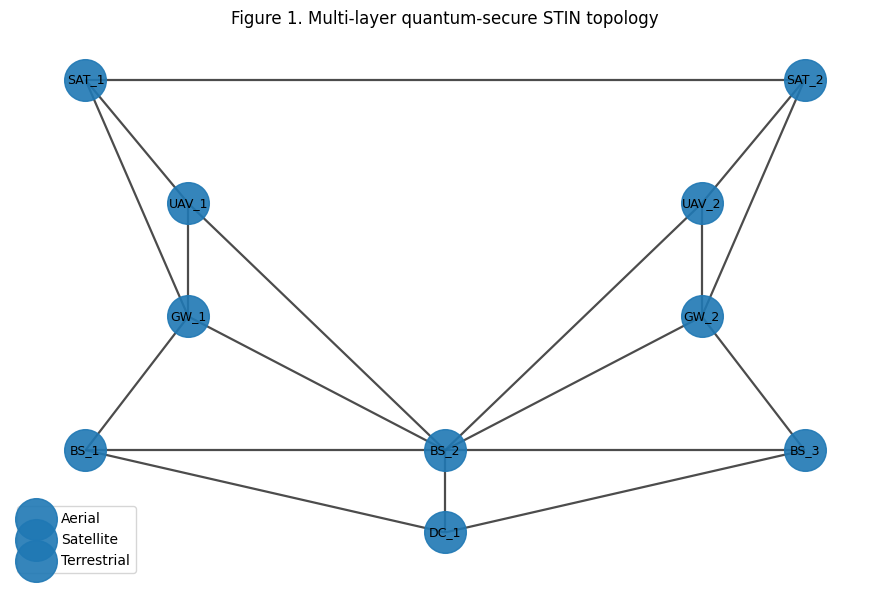

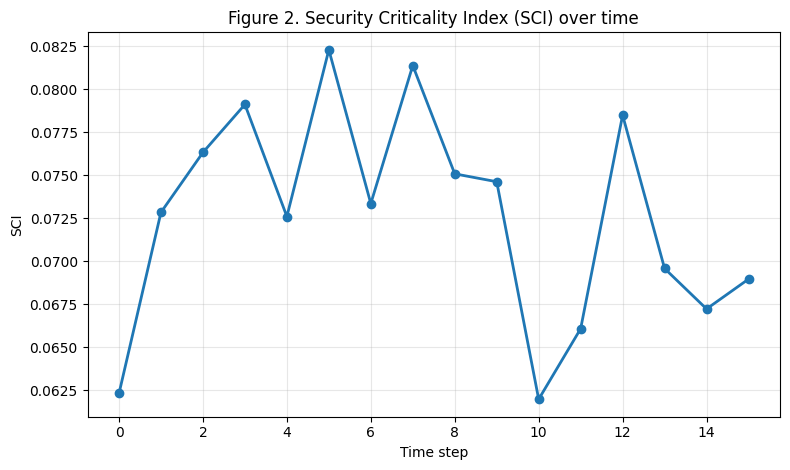

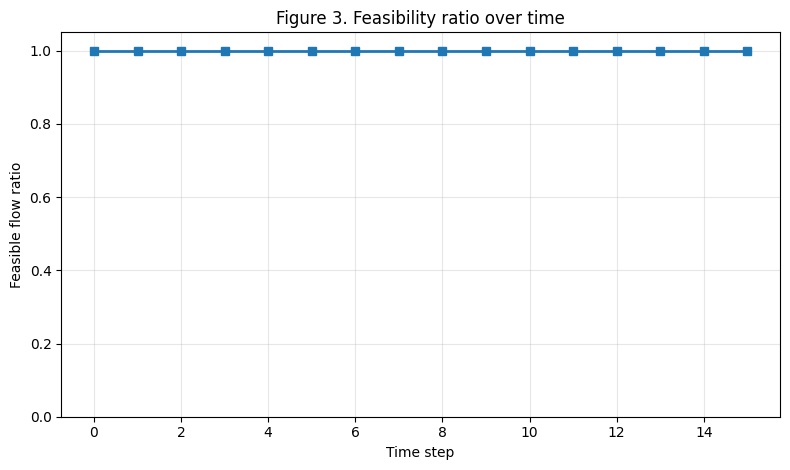

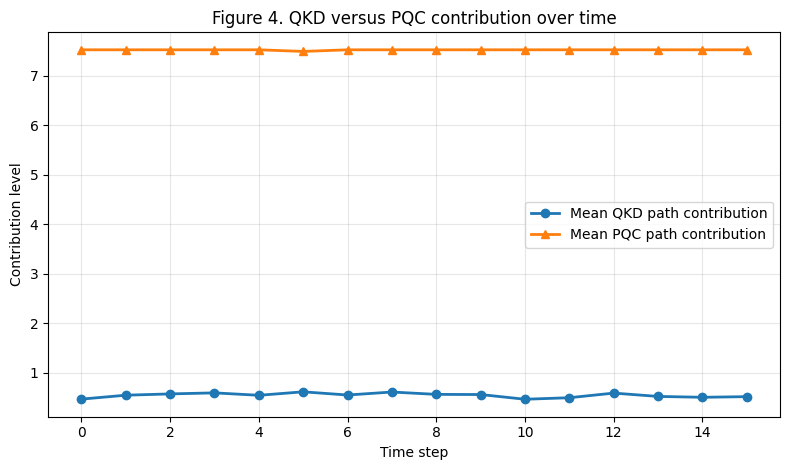

KeyError: 'latency'

<Figure size 800x500 with 0 Axes>

In [9]:

# Prepare figure-friendly data
time_df = summary_time.copy().sort_values("time")
flow_df = summary_flow.copy().reset_index()

# Figure 1: Topology
plt.figure(figsize=(9, 6))
pos = {
    "SAT_1": (0.15, 0.92), "SAT_2": (0.85, 0.92),
    "UAV_1": (0.25, 0.68), "UAV_2": (0.75, 0.68),
    "GW_1": (0.25, 0.46), "GW_2": (0.75, 0.46),
    "BS_1": (0.15, 0.20), "BS_2": (0.50, 0.20), "BS_3": (0.85, 0.20),
    "DC_1": (0.50, 0.04),
}
layer_marker = {"space": "o", "air": "s", "gateway": "D", "ground": "^", "data_center": "P"}
for layer_name in sorted({G.nodes[n]["layer"] for n in G.nodes()}):
    layer_nodes = [n for n in G.nodes() if G.nodes[n]["layer"] == layer_name]
    nx.draw_networkx_nodes(
        G, pos, nodelist=layer_nodes,
        node_shape=layer_marker.get(layer_name, "o"),
        label=layer_name.replace("_", " ").title(),
        node_size=900,
        alpha=0.9
    )
nx.draw_networkx_edges(G, pos, width=1.6, alpha=0.7)
nx.draw_networkx_labels(G, pos, font_size=9)
plt.title("Figure 1. Multi-layer quantum-secure STIN topology")
plt.axis("off")
plt.legend(frameon=True)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig1_topology.png", dpi=200, bbox_inches="tight")
plt.show()

# Figure 2: SCI vs time
plt.figure(figsize=(8, 4.8))
plt.plot(time_df["time"], time_df["SCI"], marker="o", linewidth=2)
plt.xlabel("Time step")
plt.ylabel("SCI")
plt.title("Figure 2. Security Criticality Index (SCI) over time")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig2_sci_vs_time.png", dpi=200, bbox_inches="tight")
plt.show()

# Figure 3: Feasibility vs time
plt.figure(figsize=(8, 4.8))
plt.plot(time_df["time"], time_df["feasible_ratio"], marker="s", linewidth=2)
plt.xlabel("Time step")
plt.ylabel("Feasible flow ratio")
plt.title("Figure 3. Feasibility ratio over time")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig3_feasibility_vs_time.png", dpi=200, bbox_inches="tight")
plt.show()

# Figure 4: QKD vs PQC contribution over time
plt.figure(figsize=(8, 4.8))
plt.plot(time_df["time"], time_df["mean_q_path"], marker="o", linewidth=2, label="Mean QKD path contribution")
plt.plot(time_df["time"], time_df["mean_p_path"], marker="^", linewidth=2, label="Mean PQC path contribution")
plt.xlabel("Time step")
plt.ylabel("Contribution level")
plt.title("Figure 4. QKD versus PQC contribution over time")
plt.grid(True, alpha=0.3)
plt.legend(frameon=True)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig4_qkd_vs_pqc_contribution.png", dpi=200, bbox_inches="tight")
plt.show()

# Figure 5: Security vs latency scatter
plt.figure(figsize=(8, 5))
for fid, grp in alloc_df.groupby("flow_id"):
    plt.scatter(grp["latency"], grp["security_level"], s=45, alpha=0.75, label=fid)
plt.xlabel("Latency")
plt.ylabel("Security level")
plt.title("Figure 5. Security–latency trade-off across flows")
plt.grid(True, alpha=0.3)
plt.legend(frameon=True)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig5_security_vs_latency_scatter.png", dpi=200, bbox_inches="tight")
plt.show()

# Figure 6: Functional score evolution
plt.figure(figsize=(8, 4.8))
plt.plot(time_df["time"], time_df["mean_functional_score"], marker="d", linewidth=2)
plt.xlabel("Time step")
plt.ylabel("Mean functional score")
plt.title("Figure 6. Evolution of the Quantum Security Functional")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig6_functional_score_evolution.png", dpi=200, bbox_inches="tight")
plt.show()

# Figure 7: Per-flow summary bars for paper drafting
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(flow_df))
width = 0.36
ax.bar(x - width/2, flow_df["avg_security_level"], width, label="Avg. security level")
ax.bar(x + width/2, flow_df["avg_functional_score"], width, label="Avg. functional score")
ax.set_xticks(x)
ax.set_xticklabels(flow_df["flow_id"])
ax.set_ylabel("Score")
ax.set_title("Figure 7. Per-flow security and functional performance")
ax.legend(frameon=True)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig7_per_flow_performance.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved figures:")
for fig_name in sorted(os.listdir(FIG_DIR)):
    print("-", fig_name)


## Export of a consolidated outputs summary

This final cell writes a richer textual summary tailored to paper drafting. In addition to feasibility, security, risk, functional performance, and SCI-based regime interpretation, it records the exported manuscript figures so the results can be traced quickly during writing.


In [10]:
lines = []
lines.append("Quantum-Secure 6G STIN Q1 Pioneering Prototype")
lines.append("=" * 60)
lines.append(f"Number of nodes: {G.number_of_nodes()}")
lines.append(f"Number of edges: {G.number_of_edges()}")
lines.append(f"Number of flows: {len(flows)}")
lines.append(f"Time steps: {T}")
lines.append("")

lines.append("Average flow summary:")
for _, row in summary_flow.iterrows():
    lines.append(
        f"- {row['flow_id']}: feasible_ratio={row['feasible_ratio']:.3f}, "
        f"avg_security_level={row['avg_security_level']:.4f}, "
        f"avg_functional_score={row['avg_functional_score']:.4f}, "
        f"avg_q_path={row['avg_q_path']:.4f}, avg_p_path={row['avg_p_path']:.4f}, "
        f"avg_trust={row['avg_trust']:.4f}, avg_risk={row['avg_risk']:.4f}, "
        f"avg_latency={row['avg_latency']:.2f}, dominant_regime={row['dominant_regime']}"
    )

lines.append("")
lines.append("Average time summary:")
for _, row in summary_time.iterrows():
    lines.append(
        f"- t={int(row['time'])}: feasible_flows={int(row['feasible_flows'])}, "
        f"feasible_ratio={row['feasible_ratio']:.3f}, "
        f"mean_security_level={row['mean_security_level']:.4f}, "
        f"mean_functional_score={row['mean_functional_score']:.4f}, "
        f"mean_q_path={row['mean_q_path']:.4f}, mean_p_path={row['mean_p_path']:.4f}, "
        f"mean_latency={row['mean_latency']:.2f}, mean_risk={row['mean_risk']:.4f}, "
        f"SCI={row['SCI']:.5f}, regime={row['regime']}"
    )

lines.append("")
lines.append("Regime counts:")
for _, row in regime_counts.iterrows():
    lines.append(f"- {row['regime']}: {int(row['count'])}")

lines.append("")
lines.append("Exported figures:")
for fig_name in sorted(os.listdir(FIG_DIR)):
    lines.append(f"- {fig_name}")

OUTPUTS_SUMMARY_PATH.write_text("\n".join(lines), encoding="utf-8")
print(OUTPUTS_SUMMARY_PATH.read_text(encoding="utf-8"))
print(f"[SAVED] {OUTPUTS_SUMMARY_PATH}")


Quantum-Secure 6G STIN Q1 Pioneering Prototype
Number of nodes: 10
Number of edges: 18
Number of flows: 4
Time steps: 16

Average flow summary:
- F1: feasible_ratio=1.000, avg_security_level=2.5854, avg_functional_score=1.8492, avg_q_path=0.6164, avg_p_path=7.2436, avg_trust=0.8932, avg_risk=0.0644, avg_latency=69.95, dominant_regime=transition
- F2: feasible_ratio=1.000, avg_security_level=2.6670, avg_functional_score=1.4373, avg_q_path=0.4333, avg_p_path=7.9802, avg_trust=0.8315, avg_risk=0.0941, avg_latency=74.95, dominant_regime=transition
- F3: feasible_ratio=1.000, avg_security_level=2.6247, avg_functional_score=1.3402, avg_q_path=0.4203, avg_p_path=7.8575, avg_trust=0.8515, avg_risk=0.0810, avg_latency=71.66, dominant_regime=transition
- F4: feasible_ratio=1.000, avg_security_level=2.5828, avg_functional_score=1.3831, avg_q_path=0.7158, avg_p_path=7.0130, avg_trust=0.8766, avg_risk=0.0718, avg_latency=86.64, dominant_regime=transition

Average time summary:
- t=0: feasible_flows